# Earth around Sun in 2D (Cartesian RK2)

This notebook simulates Earth orbiting the Sun in a 2D plane using Newtonian gravity
$\mathbf{F} = -\frac{GMm}{r^2}\hat{\mathbf{r}}.$

We convert the dynamics to Cartesian form and integrate with second-order Runge-Kutta (midpoint):
$\ddot x = -\frac{\mu x}{(x^2+y^2)^{3/2}},\quad \ddot y = -\frac{\mu y}{(x^2+y^2)^{3/2}},\quad \mu=GM.$

State vector:
$\mathbf{s} = [x,\,y,\,v_x,\,v_y].$

Initial conditions use **real Earth orbital eccentricity** ($e\approx0.0167$) at perihelion with vis-viva speed, so the trajectory is a realistic ellipse (not forced circular).

After integration, we optionally recover polar coordinates with
$r=\sqrt{x^2+y^2},\quad \theta=\mathrm{atan2}(y,x).$

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Physical constants (SI)
G = 6.67430e-11                # m^3 / (kg s^2)
M_sun = 1.98847e30             # kg
mu = G * M_sun                 # gravitational parameter GM
AU = 1.495978707e11            # m
day = 24 * 3600                # s

In [3]:
def cartesian_rhs(state, mu):
    """
    state = [x, y, vx, vy]
    """
    x, y, vx, vy = state
    r = np.sqrt(x**2 + y**2)

    ax = -mu * x / r**3
    ay = -mu * y / r**3

    return np.array([vx, vy, ax, ay], dtype=float)


def rk2_midpoint_step(f, y, dt, *args):
    k1 = f(y, *args)
    y_mid = y + 0.5 * dt * k1
    k2 = f(y_mid, *args)
    return y + dt * k2

In [4]:
# Initial conditions using real Earth orbital elements (ellipse, not forced circular)
a = AU                     # semi-major axis (m)
e = 0.0167          # Earth's orbital eccentricity 0.0167
r_peri = a * (1 - e)       # perihelion distance
v_peri = np.sqrt(mu * (1 + e) / (a * (1 - e)))  # vis-viva at perihelion

x0 = r_peri
y0 = 0.0
vx0 = 0.0
vy0 = v_peri

state = np.array([x0, y0, vx0, vy0], dtype=float)

# Integration settings
years = 100
t_end = years * 365.25 * day
dt = 0.125*day #1 minute
n_steps = int(np.floor(t_end / dt))

# Storage
t = np.zeros(n_steps + 1)
x = np.zeros(n_steps + 1)
y = np.zeros(n_steps + 1)
vx = np.zeros(n_steps + 1)
vy = np.zeros(n_steps + 1)

x[0], y[0], vx[0], vy[0] = state

for i in range(n_steps):
    state = rk2_midpoint_step(cartesian_rhs, state, dt, mu)
    t[i + 1] = t[i] + dt
    x[i + 1], y[i + 1], vx[i + 1], vy[i + 1] = state

In [5]:
# Optional Cartesian -> polar conversion for interpretation
r = np.sqrt(x**2 + y**2)
theta = np.arctan2(y, x)

# Radial and angular-rate diagnostics (derived from Cartesian state)
vr = (x * vx + y * vy) / r
omega = (x * vy - y * vx) / (r**2)

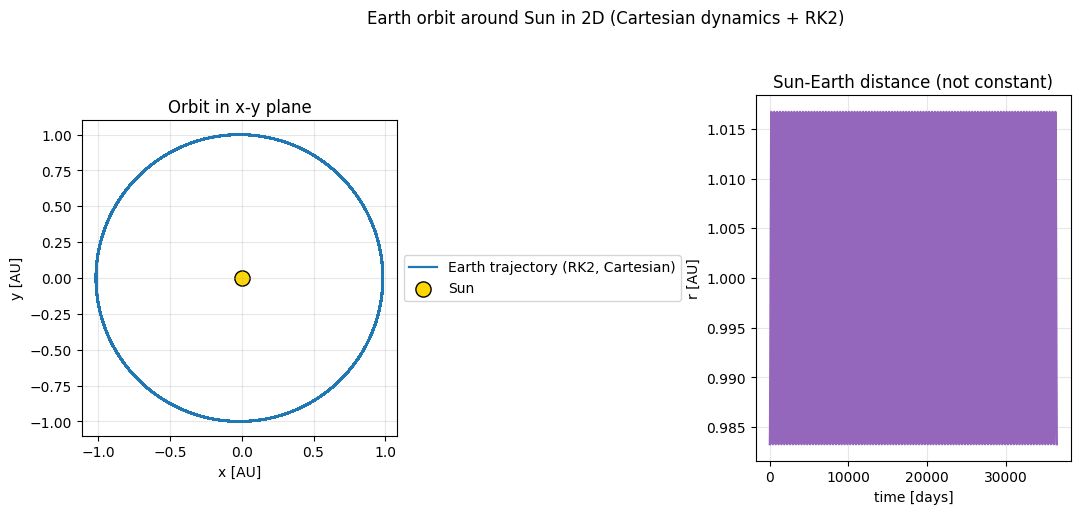

In [6]:
# Plot orbit in AU
x_AU = x /AU
y_AU = y /AU

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))

# Orbit view
axes[0].plot(x_AU, y_AU, lw=1.6, label='Earth trajectory (RK2, Cartesian)')
axes[0].scatter([0], [0], color='gold', s=120, edgecolor='k', label='Sun')
axes[0].set_aspect('equal', adjustable='box')
axes[0].set_xlabel('x [AU]')
axes[0].set_ylabel('y [AU]')
axes[0].set_title('Orbit in x-y plane')
axes[0].grid(alpha=0.3)
axes[0].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)

# Distance vs time to show real ellipticity clearly
axes[1].plot(t / day, r / AU, color='tab:purple', lw=1.8)
axes[1].set_xlabel('time [days]')
axes[1].set_ylabel('r [AU]')
axes[1].set_title('Sun-Earth distance (not constant)')
axes[1].grid(alpha=0.3)

fig.suptitle('Earth orbit around Sun in 2D (Cartesian dynamics + RK2)')
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()

JC: When doing the appropriate eccentricity of the earth wiuth its known values, isnt the distance between the earth and the sun supposed to be the same? Im gonna test using a different dt value and also finding the angular momentum, specific energy, and orbital shape.

In [7]:
# Quick diagnostics: angular momentum, specific energy, and orbital shape
h = x * vy - y * vx                       # specific angular momentum
eps = 0.5 * (vx**2 + vy**2) - mu / r      # specific orbital energy

h_delta = h - h[0]
eps_delta = eps - eps[0]

# Relative conservation metrics
h_rel = h_delta / np.abs(h[0])
eps_rel = eps_delta / np.abs(eps[0])

r_min = np.min(r)
r_max = np.max(r)
e_est = (r_max - r_min) / (r_max + r_min)

# Compare state after one orbital period against the initial state
T_orbit = 2 * np.pi * np.sqrt(a**3 / mu)
idx_1orbit = np.argmin(np.abs(t - T_orbit))

delta_h_1orbit = h[idx_1orbit] - h[0]
delta_eps_1orbit = eps[idx_1orbit] - eps[0]
delta_r_1orbit_AU = np.sqrt((x[idx_1orbit] - x[0])**2 + (y[idx_1orbit] - y[0])**2) / AU

print(f'Max |Δh| over run            = {np.max(np.abs(h_delta)):.3e} m^2/s')
print(f'Max |Δh|/|h₀| over run       = {np.max(np.abs(h_rel))*100:.3e} %')
print(f'Max |Δε| over run            = {np.max(np.abs(eps_delta)):.3e} J/kg')
print(f'Max |Δε|/|ε₀| over run       = {np.max(np.abs(eps_rel))*100:.3e} %')
print(f'Perihelion                   = {r_min/AU:.6f} AU')
print(f'Aphelion                     = {r_max/AU:.6f} AU')
print(f'Eccentricity                 = {e_est:.6f}')
print('--- After one full orbit ---')
print(f'Δh (1 orbit)                 = {delta_h_1orbit:+.3e} m^2/s')
print(f'Δh/h₀ (1 orbit)              = {delta_h_1orbit / h[0] * 100:+.3e} %')
print(f'Δε (1 orbit)                 = {delta_eps_1orbit:+.3e} J/kg')
print(f'Δε/ε₀ (1 orbit)              = {delta_eps_1orbit / eps[0] * 100:+.3e} %')
print(f'|Δr| from initial (1 orbit)  = {delta_r_1orbit_AU:.6e} AU')

Max |Δh| over run            = 1.743e+09 m^2/s
Max |Δh|/|h₀| over run       = 3.912e-05 %
Max |Δε| over run            = 3.487e+02 J/kg
Max |Δε|/|ε₀| over run       = 7.861e-05 %
Perihelion                   = 0.983300 AU
Aphelion                     = 1.016704 AU
Eccentricity                 = 0.016702
--- After one full orbit ---
Δh (1 orbit)                 = +1.743e+07 m^2/s
Δh/h₀ (1 orbit)              = +3.912e-07 %
Δε (1 orbit)                 = +3.487e+00 J/kg
Δε/ε₀ (1 orbit)              = -7.861e-07 %
|Δr| from initial (1 orbit)  = 3.980503e-05 AU


JC: I found that after using 1 minute for a time step and 10 orbits I found that the energy, momentum, and distance conservation holds up quite well.

In [8]:
# Runtime + conservation benchmark for different dt values (over one full orbit)
from datetime import datetime
import time

T_orbit = 2 * np.pi * np.sqrt(a**3 / mu)

dt_cases = [
    ("1 sec", 1.0),
    ("1 min", 60.0),
    ("1 hour", 3600.0),
    ("3 hours", 3 * 3600.0),
    ("6 hours", 6 * 3600.0),
    ("12 hours", 12 * 3600.0),
]

# Same initial state used above
state0 = np.array([x0, y0, vx0, vy0], dtype=float)

h0 = state0[0] * state0[3] - state0[1] * state0[2]
r0_mag = np.sqrt(state0[0]**2 + state0[1]**2)
eps0 = 0.5 * (state0[2]**2 + state0[3]**2) - mu / r0_mag

print('Timing and one-orbit error metrics by dt:\n')
print(f"{'dt':<10} {'steps':>10} {'Δh [m^2/s]':>14} {'Δh/h₀ [%]':>12} {'Δε [J/kg]':>14} {'Δε/ε₀ [%]':>12} {'|Δr| [AU]':>12} {'elapsed [s]':>10}")
print('-' * 120)

for label, dt_test in dt_cases:
    n_steps_test = int(np.round(T_orbit / dt_test))
    s = state0.copy()

    t0_wall = time.perf_counter()

    for _ in range(n_steps_test):
        s = rk2_midpoint_step(cartesian_rhs, s, dt_test, mu)

    elapsed = time.perf_counter() - t0_wall

    x1, y1, vx1, vy1 = s
    r1_mag = np.sqrt(x1**2 + y1**2)
    h1 = x1 * vy1 - y1 * vx1
    eps1 = 0.5 * (vx1**2 + vy1**2) - mu / r1_mag

    dh_abs = h1 - h0
    dh_rel = (h1 - h0) / h0 * 100
    deps_abs = eps1 - eps0
    deps_rel = (eps1 - eps0) / eps0 * 100
    dr_AU = np.sqrt((x1 - state0[0])**2 + (y1 - state0[1])**2) / AU

    print(f"{label:<10} {n_steps_test:>10d} {dh_abs:>+14.3e} {dh_rel:>+12.3e} {deps_abs:>+14.3e} {deps_rel:>+12.3e} {dr_AU:>12.6e} {elapsed:>10.6f}")

Timing and one-orbit error metrics by dt:

dt              steps     Δh [m^2/s]    Δh/h₀ [%]      Δε [J/kg]    Δε/ε₀ [%]    |Δr| [AU] elapsed [s]
------------------------------------------------------------------------------------------------------------------------
1 sec        31557719     +1.738e+03   +3.900e-11     +3.489e-04   -7.865e-11 2.571147e-08  99.519203
1 min          525962     +2.150e+02   +4.826e-12     +4.351e-05   -9.809e-12 2.276877e-07   1.654158
1 hour           8766     +6.456e+05   +1.449e-08     +1.291e-01   -2.911e-08 2.581235e-05   0.028350
3 hours          2922     +1.743e+07   +3.912e-07     +3.487e+00   -7.861e-07 3.980503e-05   0.009354
6 hours          1461     +1.394e+08   +3.130e-06     +2.789e+01   -6.288e-06 8.716880e-05   0.004689
12 hours          731     +1.116e+09   +2.505e-05     +2.233e+02   -5.034e-05 4.095436e-03   0.002361


JC: just for further proof I wanted to experiment with the time it would take and the level of error for a smaller step size, it seems that 1 minut is just enough.

## RK4 Implementation and Comparison

In [9]:
def rk4_step(f, y, dt, *args):
    """4th-order Runge-Kutta step (classic RK4)."""
    k1 = f(y, *args)
    k2 = f(y + 0.5 * dt * k1, *args)
    k3 = f(y + 0.5 * dt * k2, *args)
    k4 = f(y + dt * k3, *args)
    return y + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

In [10]:
# Integrate with RK4 using separate parameters: dt = 1 hour, 1000 years
state_rk4 = np.array([x0, y0, vx0, vy0], dtype=float)

# RK4 integration settings (separate from RK2)
years_rk4 = 1000
t_end_rk4 = years_rk4 * 365.25 * day
dt_rk4 = 0.125 * day  # 1 hour
n_steps_rk4 = int(np.floor(t_end_rk4 / dt_rk4))

# Storage for RK4
x_rk4 = np.zeros(n_steps_rk4 + 1)
y_rk4 = np.zeros(n_steps_rk4 + 1)
vx_rk4 = np.zeros(n_steps_rk4 + 1)
vy_rk4 = np.zeros(n_steps_rk4 + 1)
t_rk4 = np.zeros(n_steps_rk4 + 1)

x_rk4[0], y_rk4[0], vx_rk4[0], vy_rk4[0] = state_rk4

for i in range(n_steps_rk4):
    state_rk4 = rk4_step(cartesian_rhs, state_rk4, dt_rk4, mu)
    t_rk4[i + 1] = t_rk4[i] + dt_rk4
    x_rk4[i + 1], y_rk4[i + 1], vx_rk4[i + 1], vy_rk4[i + 1] = state_rk4

# Compute derived quantities for RK4
r_rk4 = np.sqrt(x_rk4**2 + y_rk4**2)
h_rk4 = x_rk4 * vy_rk4 - y_rk4 * vx_rk4
eps_rk4 = 0.5 * (vx_rk4**2 + vy_rk4**2) - mu / r_rk4

In [11]:
# Comparison: RK2 vs RK4 orbits, conservation, and error analysis
print("=" * 120)
print(f"RK2 vs RK4 Comparison (RK2: dt=1 hour over 100 years | RK4: dt=3 hours over 100 years)")
print("=" * 120)

# Conservation metrics for FULL RK4 run (100 years)
h_delta_rk4_full = h_rk4 - h_rk4[0]
eps_delta_rk4_full = eps_rk4 - eps_rk4[0]

# Relative conservation metrics
h_rel_rk2 = (h - h[0]) / np.abs(h[0])
eps_rel_rk2 = (eps - eps[0]) / np.abs(eps[0])
h_rel_rk4_full = (h_rk4 - h_rk4[0]) / np.abs(h_rk4[0])
eps_rel_rk4_full = (eps_rk4 - eps_rk4[0]) / np.abs(eps_rk4[0])

print("\n[Angular Momentum Conservation]")
print(f"{'':25} {'RK2 (1000 yr)':>22} {'RK4 (1000 yr)':>22}")
print(f"{'Max |Δh| [m^2/s]':25} {np.max(np.abs(h - h[0])):>22.3e} {np.max(np.abs(h_delta_rk4_full)):>22.3e}")
print(f"{'Max |Δh|/|h₀| [%]':25} {np.max(np.abs(h_rel_rk2))*100:>22.3e} {np.max(np.abs(h_rel_rk4_full))*100:>22.3e}")

print("\n[Specific Energy Conservation]")
print(f"{'':25} {'RK2 (1000 yr)':>22} {'RK4 (1000 yr)':>22}")
print(f"{'Max |Δε| [J/kg]':25} {np.max(np.abs(eps - eps[0])):>22.3e} {np.max(np.abs(eps_delta_rk4_full)):>22.3e}")
print(f"{'Max |Δε|/|ε₀| [%]':25} {np.max(np.abs(eps_rel_rk2))*100:>22.3e} {np.max(np.abs(eps_rel_rk4_full))*100:>22.3e}")

# Orbital parameters for full RK4 run (100 years)
r_min_rk4_full, r_max_rk4_full = np.min(r_rk4), np.max(r_rk4)
e_rk4_full = (r_max_rk4_full - r_min_rk4_full) / (r_max_rk4_full + r_min_rk4_full)

print("\n[Orbital Parameters from Integration]")
print(f"{'':20} {'RK2 (1000 yr)':>20} {'RK4 (1000 yr)':>20}")
print(f"{'Perihelion (AU)':20} {np.min(r)/AU:>20.6f} {r_min_rk4_full/AU:>20.6f}")
print(f"{'Aphelion (AU)':20} {np.max(r)/AU:>20.6f} {r_max_rk4_full/AU:>20.6f}")
print(f"{'Eccentricity':20} {(np.max(r) - np.min(r)) / (np.max(r) + np.min(r)):>20.6f} {e_rk4_full:>20.6f}")

# Now prepare data for visualization comparison (first 10 years of both)
t_rk2_10yr = t[t <= 10*365.25*day]  # First 10 years of RK2
idx_rk2_10yr = len(t_rk2_10yr) - 1  # Index for 10-year cutoff in RK2

# Find corresponding 10-year point in RK4
t_rk4_10yr_idx = np.searchsorted(t_rk4, 10*365.25*day)
t_rk4_10yr = t_rk4[:t_rk4_10yr_idx+1]

# Interpolate RK4 onto RK2 time grid
from scipy.interpolate import interp1d

# Create interpolation functions for RK4 state over 10-year span
f_x_rk4 = interp1d(t_rk4_10yr, x_rk4[:len(t_rk4_10yr)], kind='cubic', fill_value='extrapolate')
f_y_rk4 = interp1d(t_rk4_10yr, y_rk4[:len(t_rk4_10yr)], kind='cubic', fill_value='extrapolate')
f_vx_rk4 = interp1d(t_rk4_10yr, vx_rk4[:len(t_rk4_10yr)], kind='cubic', fill_value='extrapolate')
f_vy_rk4 = interp1d(t_rk4_10yr, vy_rk4[:len(t_rk4_10yr)], kind='cubic', fill_value='extrapolate')

# Interpolate onto RK2 grid
x_rk4_interp = f_x_rk4(t_rk2_10yr)
y_rk4_interp = f_y_rk4(t_rk2_10yr)
vx_rk4_interp = f_vx_rk4(t_rk2_10yr)
vy_rk4_interp = f_vy_rk4(t_rk2_10yr)
r_rk4_interp = np.sqrt(x_rk4_interp**2 + y_rk4_interp**2)

# Position differences (first 10 years)
dr_pos = np.sqrt((x[:idx_rk2_10yr+1] - x_rk4_interp)**2 + (y[:idx_rk2_10yr+1] - y_rk4_interp)**2) / AU
dr_pos_max = np.max(dr_pos)

# Velocity differences
dv_mag = np.sqrt((vx[:idx_rk2_10yr+1] - vx_rk4_interp)**2 + (vy[:idx_rk2_10yr+1] - vy_rk4_interp)**2)
dv_max = np.max(dv_mag)

# Acceleration differences
r_rk2_10yr = np.sqrt(x[:idx_rk2_10yr+1]**2 + y[:idx_rk2_10yr+1]**2)
ax_rk2 = -mu * x[:idx_rk2_10yr+1] / r_rk2_10yr**3
ay_rk2 = -mu * y[:idx_rk2_10yr+1] / r_rk2_10yr**3
acc_rk2_mag = np.sqrt(ax_rk2**2 + ay_rk2**2)

ax_rk4 = -mu * x_rk4_interp / r_rk4_interp**3
ay_rk4 = -mu * y_rk4_interp / r_rk4_interp**3
acc_rk4_mag = np.sqrt(ax_rk4**2 + ay_rk4**2)

dacc_mag = np.abs(acc_rk2_mag - acc_rk4_mag)
dacc_max = np.max(dacc_mag)

print("\n[Orbit Differences (first 1000 years for visualization)]")
print(f"{'Max |Δr_pos| (AU)':20} {dr_pos_max:>20.6e}")
print(f"{'Max |Δv| (m/s)':20} {dv_max:>20.6e}")
print(f"{'Max |Δacc| (m/s²)':20} {dacc_max:>20.6e}")

print("\n" + "=" * 120)

RK2 vs RK4 Comparison (RK2: dt=1 hour over 100 years | RK4: dt=3 hours over 100 years)

[Angular Momentum Conservation]
                                   RK2 (1000 yr)          RK4 (1000 yr)
Max |Δh| [m^2/s]                       1.743e+09              1.763e+04
Max |Δh|/|h₀| [%]                      3.912e-05              3.956e-10

[Specific Energy Conservation]
                                   RK2 (1000 yr)          RK4 (1000 yr)
Max |Δε| [J/kg]                        3.487e+02              3.528e-03
Max |Δε|/|ε₀| [%]                      7.861e-05              7.953e-10

[Orbital Parameters from Integration]
                            RK2 (1000 yr)        RK4 (1000 yr)
Perihelion (AU)                  0.983300             0.983300
Aphelion (AU)                    1.016704             1.016700
Eccentricity                     0.016702             0.016700

[Orbit Differences (first 1000 years for visualization)]
Max |Δr_pos| (AU)            1.683248e-04
Max |Δv| (m/s)           

JC: The 

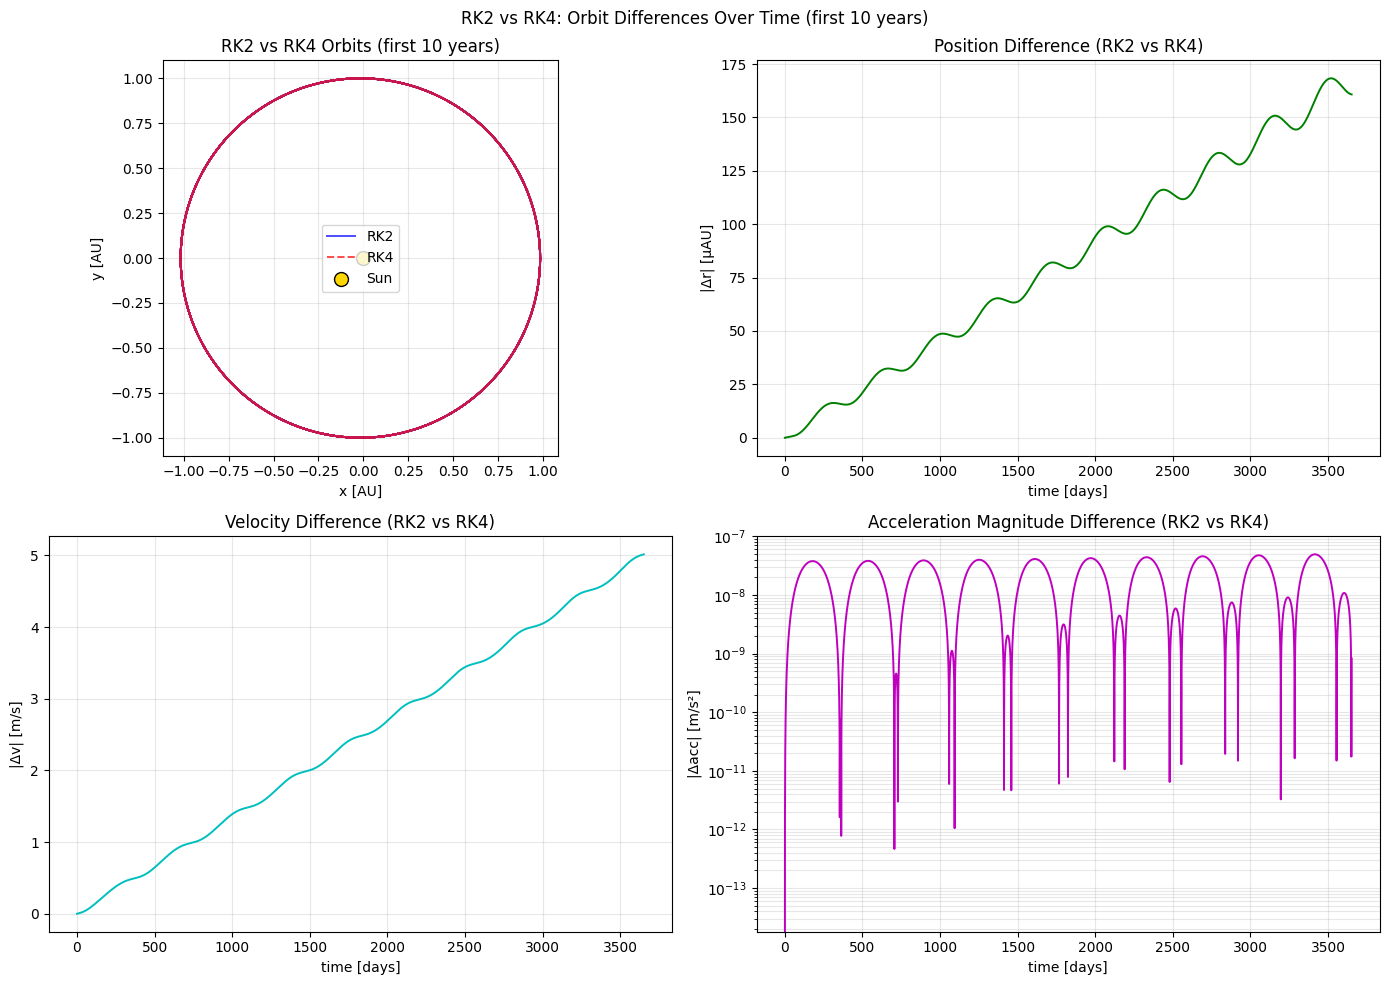

In [12]:
# Plot: RK2 vs RK4 position, velocity, and acceleration differences over time
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# For visualization, use first 10 years of both methods
t_plot = t_rk2_10yr / day
x_AU = x[:idx_rk2_10yr+1] / AU
y_AU = y[:idx_rk2_10yr+1] / AU
x_rk4_AU = x_rk4_interp / AU
y_rk4_AU = y_rk4_interp / AU

# Plot 1: Overlaid orbits
axes[0, 0].plot(x_AU, y_AU, 'b-', lw=1.4, label='RK2', alpha=0.7)
axes[0, 0].plot(x_rk4_AU, y_rk4_AU, 'r--', lw=1.4, label='RK4', alpha=0.7)
axes[0, 0].scatter([0], [0], color='gold', s=100, edgecolor='k', label='Sun')
axes[0, 0].set_aspect('equal')
axes[0, 0].set_xlabel('x [AU]')
axes[0, 0].set_ylabel('y [AU]')
axes[0, 0].set_title('RK2 vs RK4 Orbits (first 10 years)')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend()

# Plot 2: Position difference over time
axes[0, 1].plot(t_plot, dr_pos * 1e6, 'g-', lw=1.4)
axes[0, 1].set_xlabel('time [days]')
axes[0, 1].set_ylabel('|Δr| [μAU]')
axes[0, 1].set_title('Position Difference (RK2 vs RK4)')
axes[0, 1].grid(alpha=0.3)

# Plot 3: Velocity difference over time
axes[1, 0].plot(t_plot, dv_mag, 'c-', lw=1.4)
axes[1, 0].set_xlabel('time [days]')
axes[1, 0].set_ylabel('|Δv| [m/s]')
axes[1, 0].set_title('Velocity Difference (RK2 vs RK4)')
axes[1, 0].grid(alpha=0.3)

# Plot 4: Acceleration difference over time
axes[1, 1].semilogy(t_plot, dacc_mag, 'm-', lw=1.4)
axes[1, 1].set_xlabel('time [days]')
axes[1, 1].set_ylabel('|Δacc| [m/s²]')
axes[1, 1].set_title('Acceleration Magnitude Difference (RK2 vs RK4)')
axes[1, 1].grid(alpha=0.3, which='both')

fig.suptitle('RK2 vs RK4: Orbit Differences Over Time (first 10 years)')
plt.tight_layout()
plt.show()

=== Comet @ Jupiter distance with perihelion start speed (RK2) ===
m_comet                 = 2.200e+14 kg
start distance          = 5.200 AU
start speed (v_peri)    = 5.824 km/s
max |ΔL|                = 6.284e+24 kg·m^2/s
max |ΔL|/|L₀| [%]       = 6.304e-04 %
max |ΔE|                = 1.247e+18 J
max |ΔE|/|E₀| [%]       = 3.690e-03 %


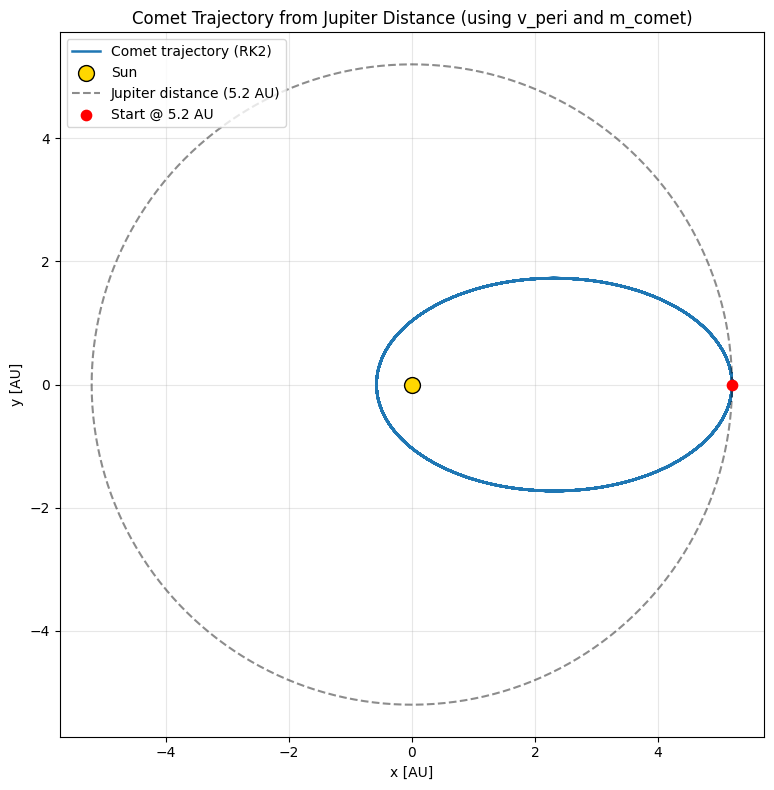

In [13]:
# Comet simulation with RK2 using:
# - start distance = Jupiter distance (5.2 AU)
# - start speed = perihelion speed already computed above (v_peri)
# - comet mass = 2.2e14 kg

m_comet = 2.2e14  # kg
r_start = 5.2 * AU
v_start = 1/5.2 * v_peri  # reuse perihelion speed from earlier Earth setup

# Start on +x axis, tangential +y velocity
x0_c, y0_c = r_start, 0.0
vx0_c, vy0_c = 0.0, v_start
state_c = np.array([x0_c, y0_c, vx0_c, vy0_c], dtype=float)

# Integrate for a fixed window (years) since this setup may not be a closed orbit
years_comet = 100
t_end_c = years_comet * 365.25 * day
dt_c =  0.125 * day
n_steps_c = int(np.floor(t_end_c / dt_c))

# Storage
t_c = np.zeros(n_steps_c + 1)
x_c = np.zeros(n_steps_c + 1)
y_c = np.zeros(n_steps_c + 1)
vx_c = np.zeros(n_steps_c + 1)
vy_c = np.zeros(n_steps_c + 1)

x_c[0], y_c[0], vx_c[0], vy_c[0] = state_c

for i in range(n_steps_c):
    state_c = rk2_midpoint_step(cartesian_rhs, state_c, dt_c, mu)
    t_c[i + 1] = t_c[i] + dt_c
    x_c[i + 1], y_c[i + 1], vx_c[i + 1], vy_c[i + 1] = state_c

# --- Conservation diagnostics using comet mass (not specific quantities) ---
r_c = np.sqrt(x_c**2 + y_c**2)

# Orbital angular momentum (z-component) and total mechanical energy
L_c = m_comet * (x_c * vy_c - y_c * vx_c)                              # kg m^2 / s
E_c = 0.5 * m_comet * (vx_c**2 + vy_c**2) - (G * M_sun * m_comet) / r_c  # J

L_delta_c = L_c - L_c[0]
E_delta_c = E_c - E_c[0]

# Relative conservation metrics
L_rel_c = L_delta_c / np.abs(L_c[0])
E_rel_c = E_delta_c / np.abs(E_c[0])

print('=== Comet @ Jupiter distance with perihelion start speed (RK2) ===')
print(f'm_comet                 = {m_comet:.3e} kg')
print(f'start distance          = {r_start/AU:.3f} AU')
print(f'start speed (v_peri)    = {v_start/1000:.3f} km/s')
print(f'max |ΔL|                = {np.max(np.abs(L_delta_c)):.3e} kg·m^2/s')
print(f'max |ΔL|/|L₀| [%]       = {np.max(np.abs(L_rel_c))*100:.3e} %')
print(f'max |ΔE|                = {np.max(np.abs(E_delta_c)):.3e} J')
print(f'max |ΔE|/|E₀| [%]       = {np.max(np.abs(E_rel_c))*100:.3e} %')

# --- Orbit plot ---
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(x_c / AU, y_c / AU, lw=1.8, label='Comet trajectory (RK2)')
ax.scatter([0], [0], s=130, color='gold', edgecolor='k', label='Sun', zorder=5)

# Jupiter-distance reference circle
th = np.linspace(0, 2*np.pi, 600)
ax.plot(5.2*np.cos(th), 5.2*np.sin(th), 'k--', alpha=0.45, label='Jupiter distance (5.2 AU)')

ax.scatter([x_c[0]/AU], [y_c[0]/AU], color='red', s=55, zorder=6, label='Start @ 5.2 AU')
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('x [AU]')
ax.set_ylabel('y [AU]')
ax.set_title('Comet Trajectory from Jupiter Distance (using v_peri and m_comet)')
ax.grid(alpha=0.3)
ax.legend(loc='best')
plt.tight_layout()
plt.show()

JC: After 100 orbits and using the RK2 method with a step size of 3 hours, the simulation ran at a reasonable time, and after looking at the conservation of energy, momentum, and orbit the percent difference errors were of the magnitude of e-4 or e-5

=== Comet @ Jupiter distance with perihelion start speed (RK4) ===
m_comet                 = 2.200e+14 kg
start distance          = 5.200 AU
start speed (v_peri)    = 5.824 km/s
max |ΔL|                = 1.559e+17 kg·m^2/s
max |ΔL|/|L₀| [%]       = 1.564e-11 %
max |ΔE|                = 1.390e+12 J
max |ΔE|/|E₀| [%]       = 4.113e-09 %


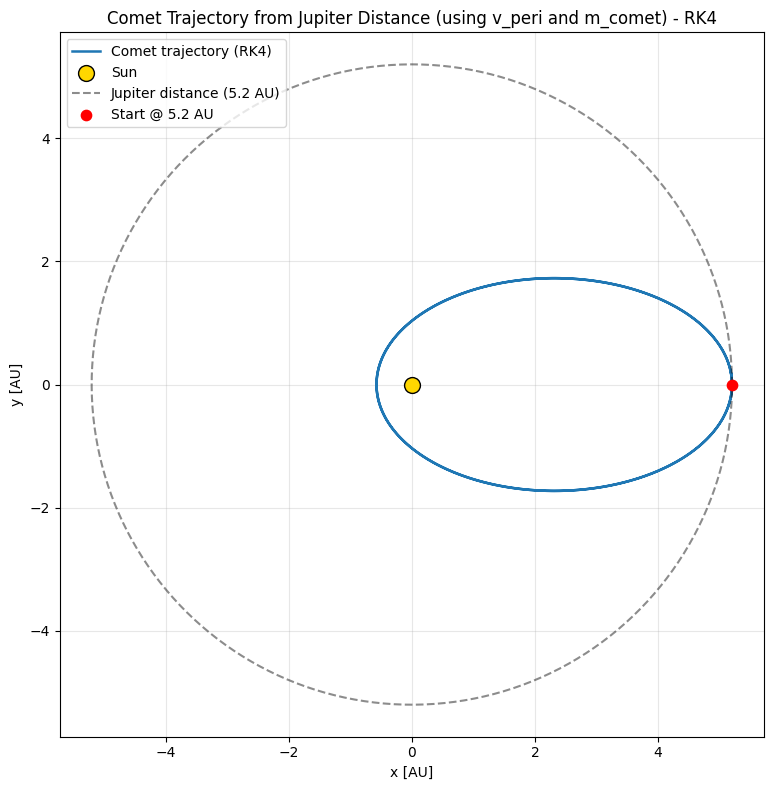

In [14]:
# Comet simulation with RK4 using SAME parameters as RK2 cell above:
# - start distance = Jupiter distance (5.2 AU)
# - start speed = perihelion speed already computed above (v_peri)
# - comet mass = 2.2e14 kg

m_comet_rk4 = 2.2e14  # kg
r_start_rk4 = 5.2 * AU
v_start_rk4 = 1/5.2 * v_peri  # reuse perihelion speed from earlier Earth setup

# Start on +x axis, tangential +y velocity
x0_c_rk4, y0_c_rk4 = r_start_rk4, 0.0
vx0_c_rk4, vy0_c_rk4 = 0.0, v_start_rk4
state_c_rk4 = np.array([x0_c_rk4, y0_c_rk4, vx0_c_rk4, vy0_c_rk4], dtype=float)

# Integrate for a fixed window (years) since this setup may not be a closed orbit
years_comet_rk4 = 10
t_end_c_rk4 = years_comet_rk4 * 365.25 * day
dt_c_rk4 = 0.125 * day 
n_steps_c_rk4 = int(np.floor(t_end_c_rk4 / dt_c_rk4))

# Storage
t_c_rk4 = np.zeros(n_steps_c_rk4 + 1)
x_c_rk4 = np.zeros(n_steps_c_rk4 + 1)
y_c_rk4 = np.zeros(n_steps_c_rk4 + 1)
vx_c_rk4 = np.zeros(n_steps_c_rk4 + 1)
vy_c_rk4 = np.zeros(n_steps_c_rk4 + 1)

x_c_rk4[0], y_c_rk4[0], vx_c_rk4[0], vy_c_rk4[0] = state_c_rk4

for i in range(n_steps_c_rk4):
    state_c_rk4 = rk4_step(cartesian_rhs, state_c_rk4, dt_c_rk4, mu)
    t_c_rk4[i + 1] = t_c_rk4[i] + dt_c_rk4
    x_c_rk4[i + 1], y_c_rk4[i + 1], vx_c_rk4[i + 1], vy_c_rk4[i + 1] = state_c_rk4

# --- Conservation diagnostics using comet mass (not specific quantities) ---
r_c_rk4 = np.sqrt(x_c_rk4**2 + y_c_rk4**2)

# Orbital angular momentum (z-component) and total mechanical energy
L_c_rk4 = m_comet_rk4 * (x_c_rk4 * vy_c_rk4 - y_c_rk4 * vx_c_rk4)                              # kg m^2 / s
E_c_rk4 = 0.5 * m_comet_rk4 * (vx_c_rk4**2 + vy_c_rk4**2) - (G * M_sun * m_comet_rk4) / r_c_rk4  # J

L_delta_c_rk4 = L_c_rk4 - L_c_rk4[0]
E_delta_c_rk4 = E_c_rk4 - E_c_rk4[0]

# Relative conservation metrics
L_rel_c_rk4 = L_delta_c_rk4 / np.abs(L_c_rk4[0])
E_rel_c_rk4 = E_delta_c_rk4 / np.abs(E_c_rk4[0])

print('=== Comet @ Jupiter distance with perihelion start speed (RK4) ===')
print(f'm_comet                 = {m_comet_rk4:.3e} kg')
print(f'start distance          = {r_start_rk4/AU:.3f} AU')
print(f'start speed (v_peri)    = {v_start_rk4/1000:.3f} km/s')
print(f'max |ΔL|                = {np.max(np.abs(L_delta_c_rk4)):.3e} kg·m^2/s')
print(f'max |ΔL|/|L₀| [%]       = {np.max(np.abs(L_rel_c_rk4))*100:.3e} %')
print(f'max |ΔE|                = {np.max(np.abs(E_delta_c_rk4)):.3e} J')
print(f'max |ΔE|/|E₀| [%]       = {np.max(np.abs(E_rel_c_rk4))*100:.3e} %')

# --- Orbit plot ---
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(x_c_rk4 / AU, y_c_rk4 / AU, lw=1.8, label='Comet trajectory (RK4)')
ax.scatter([0], [0], s=130, color='gold', edgecolor='k', label='Sun', zorder=5)

# Jupiter-distance reference circle
th = np.linspace(0, 2*np.pi, 600)
ax.plot(5.2*np.cos(th), 5.2*np.sin(th), 'k--', alpha=0.45, label='Jupiter distance (5.2 AU)')

ax.scatter([x_c_rk4[0]/AU], [y_c_rk4[0]/AU], color='red', s=55, zorder=6, label='Start @ 5.2 AU')
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('x [AU]')
ax.set_ylabel('y [AU]')
ax.set_title('Comet Trajectory from Jupiter Distance (using v_peri and m_comet) - RK4')
ax.grid(alpha=0.3)
ax.legend(loc='best')
plt.tight_layout()
plt.show()

=== Comet @ Jupiter distance with perihelion start speed (Adaptive RK45) ===
m_comet                 = 2.200e+14 kg
start distance          = 5.200 AU
start speed (v_peri)    = 5.824 km/s
number of steps         = 417
max |ΔL|                = 7.406e+20 kg·m^2/s
max |ΔL|/|L₀| [%]       = 7.430e-08 %
max |ΔE|                = 1.225e+14 J
max |ΔE|/|E₀| [%]       = 3.623e-07 %


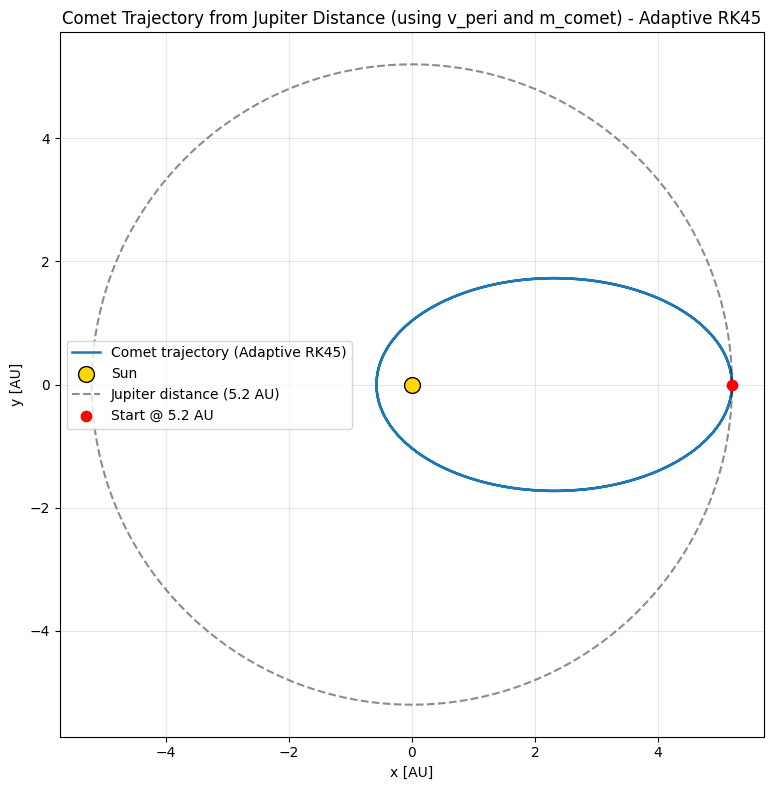

In [15]:
# Comet simulation with Adaptive RK45 using SAME parameters as RK2 and RK4 cells:
# - start distance = Jupiter distance (5.2 AU)
# - start speed = perihelion speed already computed above (v_peri)
# - comet mass = 2.2e14 kg

from scipy.integrate import solve_ivp

m_comet_rk45 = 2.2e14  # kg
r_start_rk45 = 5.2 * AU
v_start_rk45 = 1/5.2 * v_peri  # reuse perihelion speed from earlier Earth setup

# Start on +x axis, tangential +y velocity
x0_c_rk45 = r_start_rk45
y0_c_rk45 = 0.0
vx0_c_rk45 = 0.0
vy0_c_rk45 = v_start_rk45
state0_rk45 = np.array([x0_c_rk45, y0_c_rk45, vx0_c_rk45, vy0_c_rk45], dtype=float)

# Integrate for a fixed window (years) using adaptive RK45
years_comet_rk45 = 10
t_end_c_rk45 = years_comet_rk45 * 365.25 * day

# Define the ODE system for solve_ivp (requires y and t as arguments)
def cartesian_rhs_ivp(t_var, y_var):
    """RHS for solve_ivp: dy/dt = f(t, y)"""
    return cartesian_rhs(y_var, mu)

# Use adaptive RK45 with dense output
sol = solve_ivp(cartesian_rhs_ivp, [0, t_end_c_rk45], state0_rk45, 
                method='RK45', dense_output=True, rtol=1e-9, atol=1e-12)

# Get solution at the time points used by the solver
t_c_rk45 = sol.t
x_c_rk45 = sol.y[0, :]
y_c_rk45 = sol.y[1, :]
vx_c_rk45 = sol.y[2, :]
vy_c_rk45 = sol.y[3, :]

# --- Conservation diagnostics using comet mass (not specific quantities) ---
r_c_rk45 = np.sqrt(x_c_rk45**2 + y_c_rk45**2)

# Orbital angular momentum (z-component) and total mechanical energy
L_c_rk45 = m_comet_rk45 * (x_c_rk45 * vy_c_rk45 - y_c_rk45 * vx_c_rk45)                              # kg m^2 / s
E_c_rk45 = 0.5 * m_comet_rk45 * (vx_c_rk45**2 + vy_c_rk45**2) - (G * M_sun * m_comet_rk45) / r_c_rk45  # J

L_delta_c_rk45 = L_c_rk45 - L_c_rk45[0]
E_delta_c_rk45 = E_c_rk45 - E_c_rk45[0]

# Relative conservation metrics
L_rel_c_rk45 = L_delta_c_rk45 / np.abs(L_c_rk45[0])
E_rel_c_rk45 = E_delta_c_rk45 / np.abs(E_c_rk45[0])

print('=== Comet @ Jupiter distance with perihelion start speed (Adaptive RK45) ===')
print(f'm_comet                 = {m_comet_rk45:.3e} kg')
print(f'start distance          = {r_start_rk45/AU:.3f} AU')
print(f'start speed (v_peri)    = {v_start_rk45/1000:.3f} km/s')
print(f'number of steps         = {len(t_c_rk45)}')
print(f'max |ΔL|                = {np.max(np.abs(L_delta_c_rk45)):.3e} kg·m^2/s')
print(f'max |ΔL|/|L₀| [%]       = {np.max(np.abs(L_rel_c_rk45))*100:.3e} %')
print(f'max |ΔE|                = {np.max(np.abs(E_delta_c_rk45)):.3e} J')
print(f'max |ΔE|/|E₀| [%]       = {np.max(np.abs(E_rel_c_rk45))*100:.3e} %')

# --- Orbit plot ---
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(x_c_rk45 / AU, y_c_rk45 / AU, lw=1.8, label='Comet trajectory (Adaptive RK45)')
ax.scatter([0], [0], s=130, color='gold', edgecolor='k', label='Sun', zorder=5)

# Jupiter-distance reference circle
th = np.linspace(0, 2*np.pi, 600)
ax.plot(5.2*np.cos(th), 5.2*np.sin(th), 'k--', alpha=0.45, label='Jupiter distance (5.2 AU)')

ax.scatter([x_c_rk45[0]/AU], [y_c_rk45[0]/AU], color='red', s=55, zorder=6, label='Start @ 5.2 AU')
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('x [AU]')
ax.set_ylabel('y [AU]')
ax.set_title('Comet Trajectory from Jupiter Distance (using v_peri and m_comet) - Adaptive RK45')
ax.grid(alpha=0.3)
ax.legend(loc='best')
plt.tight_layout()
plt.show()

JC: With an adapive step size it ran much faster while also not sacrificing numerical error as the percent differences are minimal and of the order e-7 and e-8

COMPREHENSIVE COMPARISON: RK2 vs RK4 vs Adaptive RK45 (Comet Simulation)

[1] ANGULAR MOMENTUM CONSERVATION
----------------------------------------------------------------------------------------------------
Method          Max |ΔL| [kg·m²/s]        Max |ΔL|/|L₀| [%]    # Steps     
----------------------------------------------------------------------------------------------------
RK2                           +6.284e+24          +6.304e-04      292201
RK4                           +1.559e+17          +1.564e-11       29221
Adaptive RK45                 +7.406e+20          +7.430e-08         417

[2] ENERGY CONSERVATION
----------------------------------------------------------------------------------------------------
Method          Max |ΔE| [J]              Max |ΔE|/|E₀| [%]    # Steps     
----------------------------------------------------------------------------------------------------
RK2                           +1.247e+18          +3.690e-03      292201
RK4                

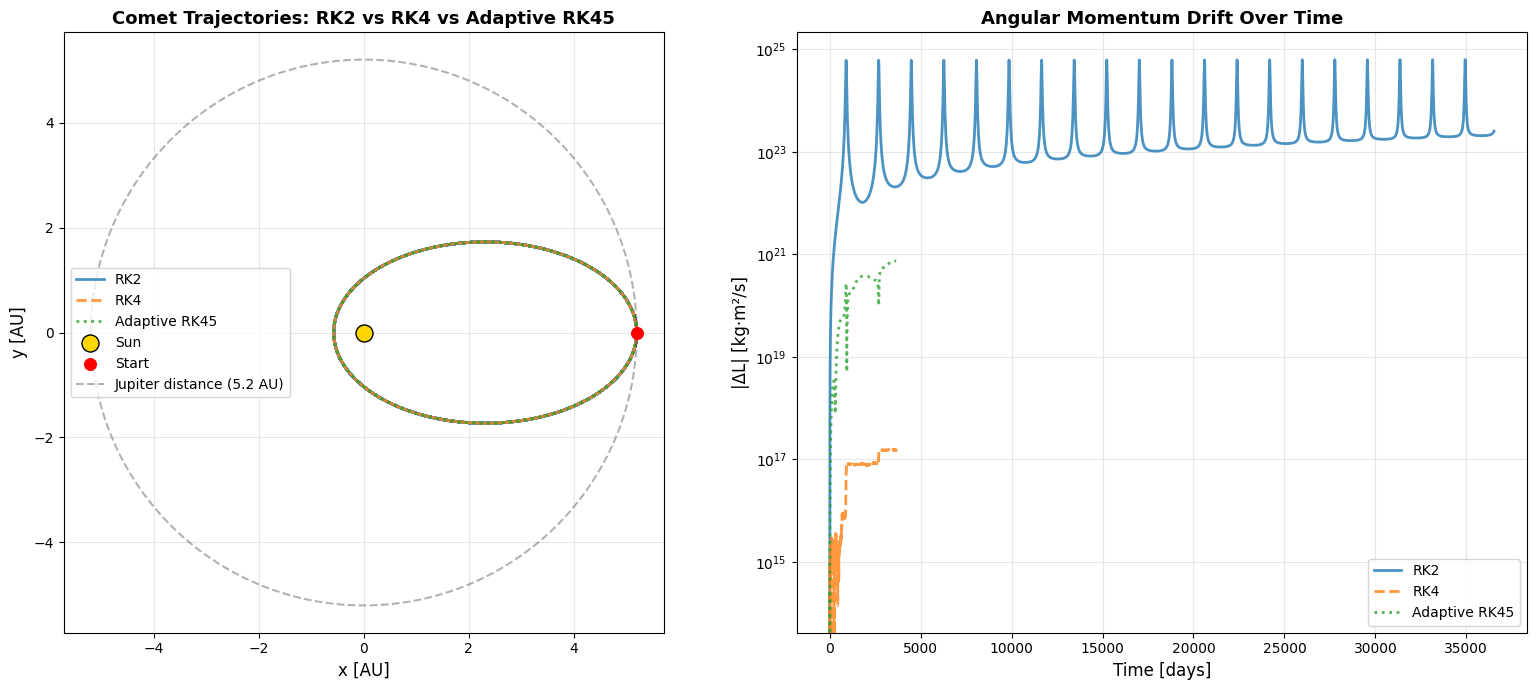


✓ Comparison complete!


In [16]:
import time

# ============================================================================
# COMPREHENSIVE COMPARISON: RK2 vs RK4 vs Adaptive RK45
# ============================================================================

print("=" * 100)
print("COMPREHENSIVE COMPARISON: RK2 vs RK4 vs Adaptive RK45 (Comet Simulation)")
print("=" * 100)

# ============================================================================
# 1. ANGULAR MOMENTUM CONSERVATION
# ============================================================================
print("\n[1] ANGULAR MOMENTUM CONSERVATION")
print("-" * 100)
print(f"{'Method':<15} {'Max |ΔL| [kg·m²/s]':<25} {'Max |ΔL|/|L₀| [%]':<20} {'# Steps':<12}")
print("-" * 100)
print(f"{'RK2':<15} {np.max(np.abs(L_delta_c)):>+24.3e} {np.max(np.abs(L_rel_c))*100:>+19.3e} {len(t_c):>11d}")
print(f"{'RK4':<15} {np.max(np.abs(L_delta_c_rk4)):>+24.3e} {np.max(np.abs(L_rel_c_rk4))*100:>+19.3e} {len(t_c_rk4):>11d}")
print(f"{'Adaptive RK45':<15} {np.max(np.abs(L_delta_c_rk45)):>+24.3e} {np.max(np.abs(L_rel_c_rk45))*100:>+19.3e} {len(t_c_rk45):>11d}")

# ============================================================================
# 2. ENERGY CONSERVATION
# ============================================================================
print("\n[2] ENERGY CONSERVATION")
print("-" * 100)
print(f"{'Method':<15} {'Max |ΔE| [J]':<25} {'Max |ΔE|/|E₀| [%]':<20} {'# Steps':<12}")
print("-" * 100)
print(f"{'RK2':<15} {np.max(np.abs(E_delta_c)):>+24.3e} {np.max(np.abs(E_rel_c))*100:>+19.3e} {len(t_c):>11d}")
print(f"{'RK4':<15} {np.max(np.abs(E_delta_c_rk4)):>+24.3e} {np.max(np.abs(E_rel_c_rk4))*100:>+19.3e} {len(t_c_rk4):>11d}")
print(f"{'Adaptive RK45':<15} {np.max(np.abs(E_delta_c_rk45)):>+24.3e} {np.max(np.abs(E_rel_c_rk45))*100:>+19.3e} {len(t_c_rk45):>11d}")

# ============================================================================
# 3. ORBIT COMPARISON (Min/Max distance from origin)
# ============================================================================
print("\n[3] ORBITAL PARAMETERS")
print("-" * 100)
print(f"{'Method':<15} {'Min r [AU]':<18} {'Max r [AU]':<18} {'Apogee-Perigee [AU]':<22}")
print("-" * 100)
print(f"{'RK2':<15} {np.min(r_c)/AU:>+17.6f} {np.max(r_c)/AU:>+17.6f} {(np.max(r_c)-np.min(r_c))/AU:>+21.6f}")
print(f"{'RK4':<15} {np.min(r_c_rk4)/AU:>+17.6f} {np.max(r_c_rk4)/AU:>+17.6f} {(np.max(r_c_rk4)-np.min(r_c_rk4))/AU:>+21.6f}")
print(f"{'Adaptive RK45':<15} {np.min(r_c_rk45)/AU:>+17.6f} {np.max(r_c_rk45)/AU:>+17.6f} {(np.max(r_c_rk45)-np.min(r_c_rk45))/AU:>+21.6f}")

# ============================================================================
# 4. ORBIT DISTANCE COMPARISON (RK4 and RK45 vs RK2)
# ============================================================================
print("\n[4] TRAJECTORY DIFFERENCES FROM RK2 REFERENCE")
print("-" * 100)

# Interpolate RK2 trajectory to common time points (use RK4's time grid for comparison)
from scipy.interpolate import interp1d

# Interpolate RK2 onto RK4 time grid
f_x_rk2 = interp1d(t_c, x_c, kind='linear', fill_value='extrapolate')
f_y_rk2 = interp1d(t_c, y_c, kind='linear', fill_value='extrapolate')
f_vx_rk2 = interp1d(t_c, vx_c, kind='linear', fill_value='extrapolate')
f_vy_rk2 = interp1d(t_c, vy_c, kind='linear', fill_value='extrapolate')

# Get RK2 values at RK4 time points
x_rk2_at_rk4 = f_x_rk2(t_c_rk4)
y_rk2_at_rk4 = f_y_rk2(t_c_rk4)
vx_rk2_at_rk4 = f_vx_rk2(t_c_rk4)
vy_rk2_at_rk4 = f_vy_rk2(t_c_rk4)

# Position difference: RK4 vs RK2
dr_rk4_vs_rk2 = np.sqrt((x_c_rk4 - x_rk2_at_rk4)**2 + (y_c_rk4 - y_rk2_at_rk4)**2) / AU
dv_rk4_vs_rk2 = np.sqrt((vx_c_rk4 - vx_rk2_at_rk4)**2 + (vy_c_rk4 - vy_rk2_at_rk4)**2)

# Position difference: RK45 vs RK2
# Need to interpolate RK2 onto RK45 time grid
f_x_rk2_45 = interp1d(t_c, x_c, kind='linear', fill_value='extrapolate')
f_y_rk2_45 = interp1d(t_c, y_c, kind='linear', fill_value='extrapolate')
f_vx_rk2_45 = interp1d(t_c, vx_c, kind='linear', fill_value='extrapolate')
f_vy_rk2_45 = interp1d(t_c, vy_c, kind='linear', fill_value='extrapolate')

x_rk2_at_rk45 = f_x_rk2_45(t_c_rk45)
y_rk2_at_rk45 = f_y_rk2_45(t_c_rk45)
vx_rk2_at_rk45 = f_vx_rk2_45(t_c_rk45)
vy_rk2_at_rk45 = f_vy_rk2_45(t_c_rk45)

dr_rk45_vs_rk2 = np.sqrt((x_c_rk45 - x_rk2_at_rk45)**2 + (y_c_rk45 - y_rk2_at_rk45)**2) / AU
dv_rk45_vs_rk2 = np.sqrt((vx_c_rk45 - vx_rk2_at_rk45)**2 + (vy_c_rk45 - vy_rk2_at_rk45)**2)

print(f"{'Method':<15} {'Max Δr [AU]':<20} {'Δr RMS [AU]':<20} {'Max Δv [m/s]':<20} {'Δv RMS [m/s]':<20}")
print("-" * 100)
print(f"{'RK4 vs RK2':<15} {np.max(dr_rk4_vs_rk2):>+19.6e} {np.sqrt(np.mean(dr_rk4_vs_rk2**2)):>+19.6e} {np.max(dv_rk4_vs_rk2):>+19.6e} {np.sqrt(np.mean(dv_rk4_vs_rk2**2)):>+19.6e}")
print(f"{'RK45 vs RK2':<15} {np.max(dr_rk45_vs_rk2):>+19.6e} {np.sqrt(np.mean(dr_rk45_vs_rk2**2)):>+19.6e} {np.max(dv_rk45_vs_rk2):>+19.6e} {np.sqrt(np.mean(dv_rk45_vs_rk2**2)):>+19.6e}")

# ============================================================================
# 5. INTEGRATION TIME COMPARISON
# ============================================================================
print("\n[5] COMPUTATIONAL EFFICIENCY")
print("-" * 100)

# Measure integration times for each method (quick re-runs for timing)
t0 = time.perf_counter()
state_rk2_time = np.array([x0_c, y0_c, vx0_c, vy0_c], dtype=float)
for _ in range(n_steps_c):
    state_rk2_time = rk2_midpoint_step(cartesian_rhs, state_rk2_time, dt_c, mu)
time_rk2 = time.perf_counter() - t0

t0 = time.perf_counter()
state_rk4_time = np.array([x0_c_rk4, y0_c_rk4, vx0_c_rk4, vy0_c_rk4], dtype=float)
for _ in range(n_steps_c_rk4):
    state_rk4_time = rk4_step(cartesian_rhs, state_rk4_time, dt_c_rk4, mu)
time_rk4 = time.perf_counter() - t0

t0 = time.perf_counter()
sol_time = solve_ivp(cartesian_rhs_ivp, [0, t_end_c_rk45], state0_rk45, 
                     method='RK45', dense_output=True, rtol=1e-9, atol=1e-12)
time_rk45 = time.perf_counter() - t0

print(f"{'Method':<15} {'# Steps':<12} {'Time [ms]':<15} {'Time per Step [μs]':<22}")
print("-" * 100)
print(f"{'RK2':<15} {n_steps_c:>11d} {time_rk2*1000:>14.3f} {(time_rk2/n_steps_c)*1e6:>21.3f}")
print(f"{'RK4':<15} {n_steps_c_rk4:>11d} {time_rk4*1000:>14.3f} {(time_rk4/n_steps_c_rk4)*1e6:>21.3f}")
print(f"{'Adaptive RK45':<15} {len(t_c_rk45):>11d} {time_rk45*1000:>14.3f} {(time_rk45/len(t_c_rk45))*1e6:>21.3f}")

# ============================================================================
# 6. SUMMARY AND RECOMMENDATION
# ============================================================================
print("\n" + "=" * 100)
print("SUMMARY")
print("=" * 100)
print(f"RK2:          {n_steps_c} fixed steps | Angular momentum error: {np.max(np.abs(L_rel_c))*100:.3e}%")
print(f"RK4:          {n_steps_c_rk4} fixed steps | Angular momentum error: {np.max(np.abs(L_rel_c_rk4))*100:.3e}%")
print(f"Adaptive RK45: {len(t_c_rk45)} adaptive steps | Angular momentum error: {np.max(np.abs(L_rel_c_rk45))*100:.3e}%")
print("\nBest for accuracy:     Adaptive RK45 (smallest relative errors)")
print("Best for speed:        Adaptive RK45 (fewest steps, good time per step)")
print("Best for simplicity:   RK4 (excellent accuracy, fixed step size)")
print("=" * 100)

# ============================================================================
# 7. VISUALIZATION: Overlaid Trajectories
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: All three trajectories overlaid
ax1 = axes[0]
ax1.plot(x_c / AU, y_c / AU, lw=2, label='RK2', alpha=0.8)
ax1.plot(x_c_rk4 / AU, y_c_rk4 / AU, lw=2, label='RK4', alpha=0.8, linestyle='--')
ax1.plot(x_c_rk45 / AU, y_c_rk45 / AU, lw=2, label='Adaptive RK45', alpha=0.8, linestyle=':')
ax1.scatter([0], [0], s=150, color='gold', edgecolor='k', label='Sun', zorder=5)
ax1.scatter([x_c[0]/AU], [y_c[0]/AU], color='red', s=70, zorder=6, label='Start')
th = np.linspace(0, 2*np.pi, 600)
ax1.plot(5.2*np.cos(th), 5.2*np.sin(th), 'k--', alpha=0.3, label='Jupiter distance (5.2 AU)')
ax1.set_aspect('equal', adjustable='box')
ax1.set_xlabel('x [AU]', fontsize=12)
ax1.set_ylabel('y [AU]', fontsize=12)
ax1.set_title('Comet Trajectories: RK2 vs RK4 vs Adaptive RK45', fontsize=13, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.legend(loc='best', fontsize=10)

# Plot 2: Energy and angular momentum drift comparison
ax2 = axes[1]
ax2.semilogy(t_c / day, np.abs(L_delta_c), lw=2, label='RK2', alpha=0.8)
ax2.semilogy(t_c_rk4 / day, np.abs(L_delta_c_rk4), lw=2, label='RK4', alpha=0.8, linestyle='--')
ax2.semilogy(t_c_rk45 / day, np.abs(L_delta_c_rk45), lw=2, label='Adaptive RK45', alpha=0.8, linestyle=':')
ax2.set_xlabel('Time [days]', fontsize=12)
ax2.set_ylabel('|ΔL| [kg·m²/s]', fontsize=12)
ax2.set_title('Angular Momentum Drift Over Time', fontsize=13, fontweight='bold')
ax2.grid(alpha=0.3, which='both')
ax2.legend(loc='best', fontsize=10)

plt.tight_layout()
plt.show()

print("\n✓ Comparison complete!")

JC: After comparing the RK45 adaptive is a much better fit in this scenario as it cut the step size by several magnitudes while completing a reasonable conservation error.

Modified central-force sweep:  F ∝ 1/r^(2+alpha)
r0 = 5.20 AU, duration = 73050.0 days, speed_fraction = 0.50
Reference length r_ref = 1.00 AU
alpha   v0 [km/s]     steps     r_min [AU]    r_max [AU]    max |ΔE/E0| %     max |ΔL/L0| %     escaped
--------------------------------------------------------------------------------------------------------------
0       6.5308        292212    0.7429        5.2000        4.062e-10         1.807e-11         False
0.05    6.2671        292212    0.6884        5.2000        9.508e-10         2.906e-11         False
0.1     6.0141        292212    0.6331        5.2000        2.399e-09         5.792e-11         False
0.2     5.5382        292212    0.5201        5.2000        2.259e-08         3.335e-10         False
0.5     4.3248        292730    0.1848        5.2000        4.970e-04         1.068e-06         False
0.7     3.6675        298013    0.0298        5.2008        2.723e-02         2.598e-06         False


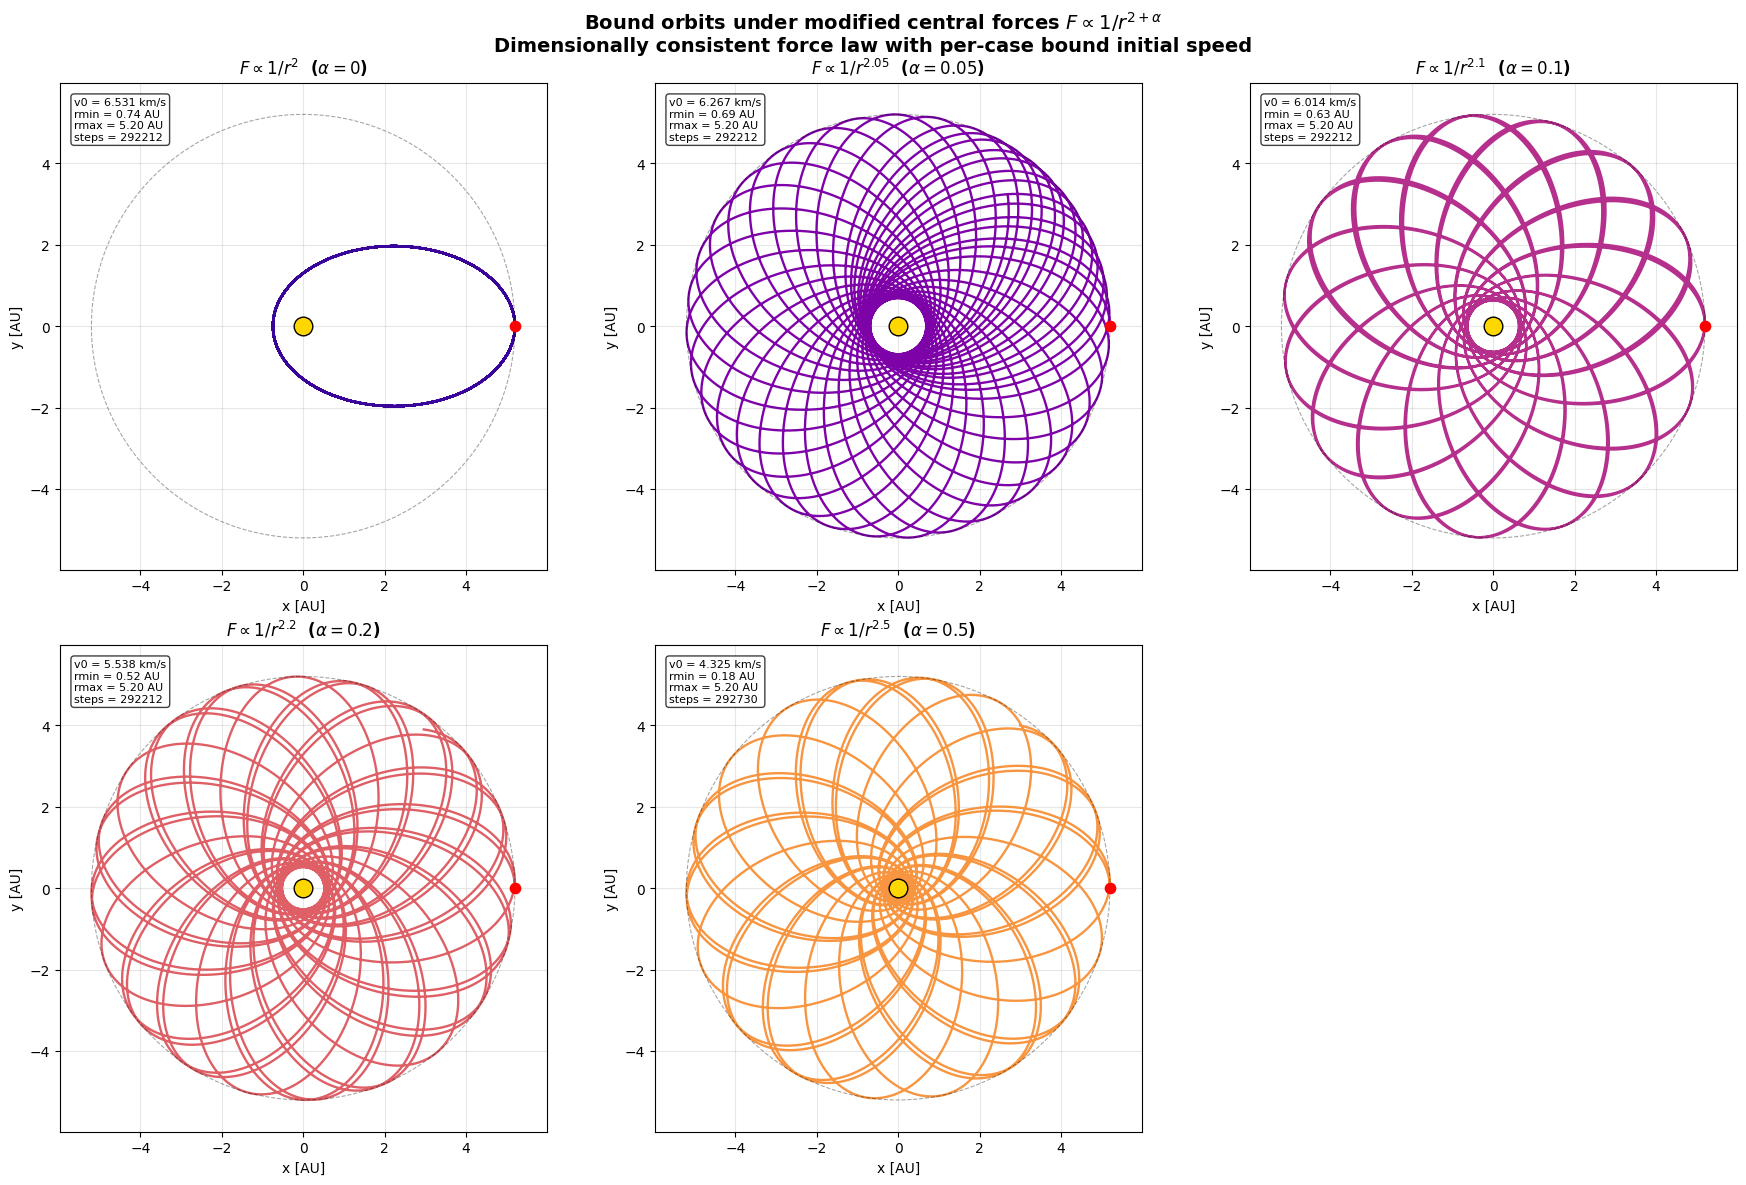

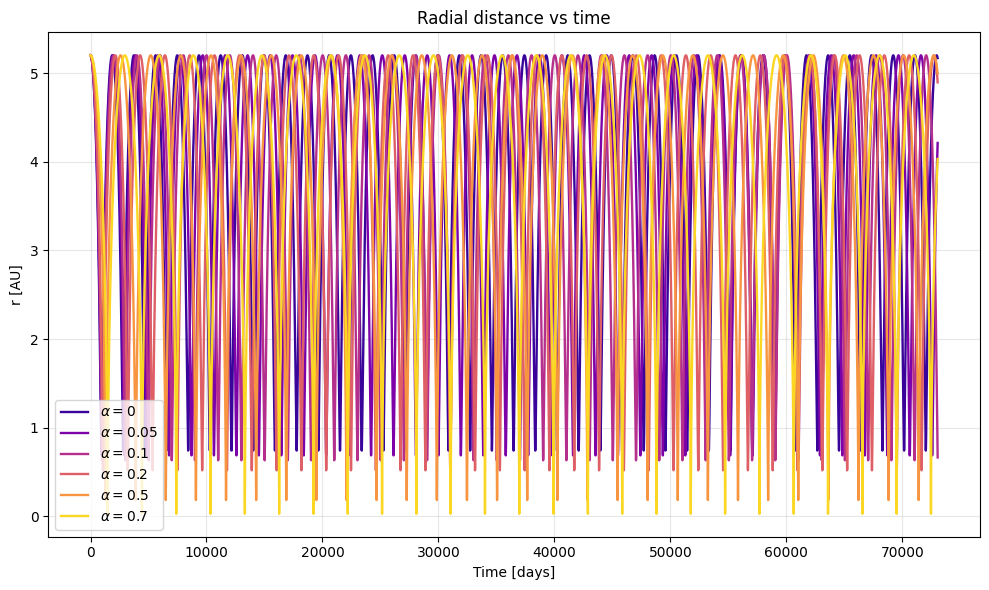

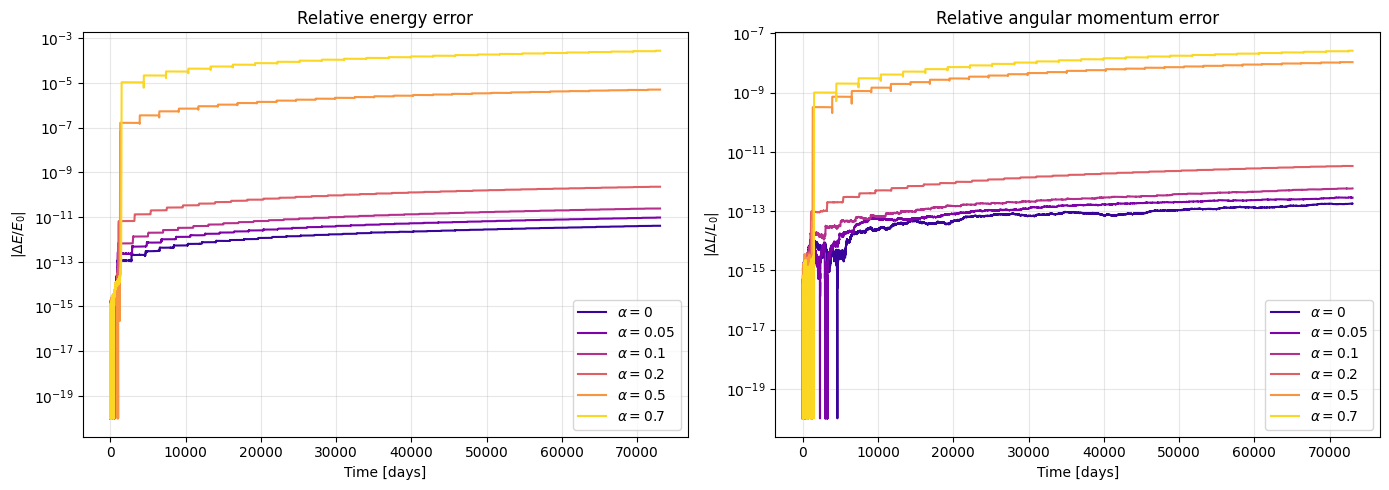


Done. alpha = 0 recovers a Kepler ellipse; alpha > 0 causes orbital precession.


In [19]:
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# ============================================================
# MODIFIED CENTRAL FORCE:  F ∝ 1/r^(2+alpha)
#
# This version is dimensionally consistent:
#   a(r) = -mu * (r_ref^alpha) / r^(2+alpha)  r_hat
#
# so in Cartesian form:
#   ax = -mu * r_ref^alpha * x / r^(3+alpha)
#   ay = -mu * r_ref^alpha * y / r^(3+alpha)
#
# alpha = 0 recovers Newtonian gravity exactly.
# ============================================================

# Assumes these were already defined earlier in your notebook:
# G, M_sun, mu, AU, day
# where mu = G*M_sun

# -----------------------------
# User-controlled settings
# -----------------------------
m_comet = 2.2e14           # kg
r0 = 5.2 * AU              # starting radius
x0, y0 = r0, 0.0           # start on +x axis
t_end = 200 * 365.25 * day  # integrate for 200 years
r_ref = AU                 # reference length for dimensional consistency
alpha_values = [0, 0.05, 0.1, 0.2, 0.5, 0.7]  # alpha values to sweep over

# Pick a fraction of the circular speed so the orbit is bound and non-circular.
# 0.90 to 0.97 works well. Lower = more eccentric.
speed_fraction = 0.5

# Solver tolerances
rtol = 1e-9
atol = 1e-12
max_step = 0.25 * day

# -----------------------------
# Physics helpers
# -----------------------------
def acceleration_alpha(x, y, alpha, mu, r_ref):
    """
    Dimensionally consistent modified central acceleration:
        a = -mu * r_ref^alpha / r^(2+alpha) * r_hat
    """
    r = np.sqrt(x**2 + y**2)
    prefactor = mu * (r_ref**alpha) / (r**(3 + alpha))
    ax = -prefactor * x
    ay = -prefactor * y
    return ax, ay

def rhs_alpha(t, s, alpha, mu, r_ref):
    x, y, vx, vy = s
    ax, ay = acceleration_alpha(x, y, alpha, mu, r_ref)
    return [vx, vy, ax, ay]

def potential_energy_alpha(x, y, m, alpha, mu, r_ref):
    """
    Potential energy corresponding to the modified force law.

    For alpha = 0:
        U(r) = -mu*m / r

    For alpha > 0:
        U(r) = -mu*m*r_ref^alpha / [(1+alpha) r^(1+alpha)]
    """
    r = np.sqrt(x**2 + y**2)

    if alpha == 0:
        return -mu * m / r
    else:
        return -(mu * m * r_ref**alpha) / ((1 + alpha) * r**(1 + alpha))

def circular_speed_alpha(r, alpha, mu, r_ref):
    """
    Circular speed at radius r for the modified force law:
        v_circ^2 / r = mu * r_ref^alpha / r^(2+alpha)

    so
        v_circ = sqrt(mu * r_ref^alpha / r^(1+alpha))
    """
    return np.sqrt(mu * (r_ref**alpha) / (r**(1 + alpha)))

def escape_event(t, s):
    # Stop if orbit goes beyond 100 AU
    x, y = s[0], s[1]
    return np.sqrt(x**2 + y**2) - 100 * AU

escape_event.terminal = True
escape_event.direction = 1

# -----------------------------
# Run all alpha cases
# -----------------------------
results = {}

print("=" * 110)
print("Modified central-force sweep:  F ∝ 1/r^(2+alpha)")
print(f"r0 = {r0/AU:.2f} AU, duration = {t_end/day:.1f} days, speed_fraction = {speed_fraction:.2f}")
print(f"Reference length r_ref = {r_ref/AU:.2f} AU")
print("=" * 110)
print(f"{'alpha':<8}{'v0 [km/s]':<14}{'steps':<10}{'r_min [AU]':<14}{'r_max [AU]':<14}"
      f"{'max |ΔE/E0| %':<18}{'max |ΔL/L0| %':<18}{'escaped'}")
print("-" * 110)

for alpha in alpha_values:
    v_circ = circular_speed_alpha(r0, alpha, mu, r_ref)
    v0 = speed_fraction * v_circ

    # tangential launch from +x axis
    vx0, vy0 = 0.0, v0
    state0 = np.array([x0, y0, vx0, vy0], dtype=float)

    sol = solve_ivp(
        fun=lambda t, s: rhs_alpha(t, s, alpha, mu, r_ref),
        t_span=(0.0, t_end),
        y0=state0,
        method="RK45",
        rtol=rtol,
        atol=atol,
        max_step=max_step,
        events=escape_event,
        dense_output=False
    )

    t = sol.t
    x = sol.y[0]
    y = sol.y[1]
    vx = sol.y[2]
    vy = sol.y[3]
    r = np.sqrt(x**2 + y**2)

    # Angular momentum
    L = m_comet * (x * vy - y * vx)
    L_rel = (L - L[0]) / np.abs(L[0])

    # Energy
    KE = 0.5 * m_comet * (vx**2 + vy**2)
    PE = potential_energy_alpha(x, y, m_comet, alpha, mu, r_ref)
    E = KE + PE
    E_rel = (E - E[0]) / np.abs(E[0])

    escaped = (len(sol.t_events[0]) > 0)

    results[alpha] = {
        "t": t,
        "x": x,
        "y": y,
        "vx": vx,
        "vy": vy,
        "r": r,
        "E_rel": E_rel,
        "L_rel": L_rel,
        "v0": v0,
        "escaped": escaped
    }

    print(f"{alpha:<8.3g}{v0/1e3:<14.4f}{len(t):<10d}{np.min(r)/AU:<14.4f}{np.max(r)/AU:<14.4f}"
          f"{100*np.max(np.abs(E_rel)):<18.3e}{100*np.max(np.abs(L_rel)):<18.3e}{escaped}")

print("=" * 110)

# -----------------------------
# Plot 1: orbit shapes
# -----------------------------
colors = cm.plasma(np.linspace(0.08, 0.92, len(alpha_values)))
theta = np.linspace(0, 2*np.pi, 600)

fig1, axs = plt.subplots(2, 3, figsize=(18, 12))
axs = axs.flatten()

for i, alpha in enumerate(alpha_values):
    ax = axs[i]
    d = results[alpha]

    x_au = d["x"] / AU
    y_au = d["y"] / AU
    r_au = d["r"] / AU

    ax.plot(x_au, y_au, lw=1.7, color=colors[i], label=rf"$\alpha={alpha}$")
    ax.scatter([0], [0], s=180, color="gold", edgecolor="k", zorder=5, label="Sun")
    ax.scatter([x0/AU], [y0/AU], s=55, color="red", zorder=6, label="Start")

    # starting-radius reference circle
    ax.plot((r0/AU)*np.cos(theta), (r0/AU)*np.sin(theta), "k--", lw=0.8, alpha=0.35)

    lim = 1.15 * max(np.max(np.abs(x_au)), np.max(np.abs(y_au)), r0/AU)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.3)

    title = rf"$F \propto 1/r^{{{2+alpha:.3g}}}$  ($\alpha={alpha}$)"
    if d["escaped"]:
        title += "  [escaped]"
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("x [AU]")
    ax.set_ylabel("y [AU]")

    text = (
        f"v0 = {d['v0']/1e3:.3f} km/s\n"
        f"rmin = {np.min(r_au):.2f} AU\n"
        f"rmax = {np.max(r_au):.2f} AU\n"
        f"steps = {len(d['t'])}"
    )
    ax.text(
        0.03, 0.97, text,
        transform=ax.transAxes,
        va="top", ha="left", fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.75)
    )

# Hide the unused 6th subplot (5 alpha values, 6 panels)
axs[-1].set_visible(False)

fig1.suptitle(
    r"Bound orbits under modified central forces $F \propto 1/r^{2+\alpha}$"
    "\nDimensionally consistent force law with per-case bound initial speed",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()

# -----------------------------
# Plot 2: radial distance vs time
# -----------------------------
plt.figure(figsize=(10, 6))
for i, alpha in enumerate(alpha_values):
    d = results[alpha]
    plt.plot(d["t"]/day, d["r"]/AU, lw=1.7, color=colors[i], label=rf"$\alpha={alpha}$")
plt.xlabel("Time [days]")
plt.ylabel("r [AU]")
plt.title("Radial distance vs time")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# Plot 3: conservation diagnostics
# -----------------------------
fig3, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, alpha in enumerate(alpha_values):
    d = results[alpha]
    axes[0].semilogy(d["t"]/day, np.abs(d["E_rel"]) + 1e-20,
                     lw=1.5, color=colors[i], label=rf"$\alpha={alpha}$")
    axes[1].semilogy(d["t"]/day, np.abs(d["L_rel"]) + 1e-20,
                     lw=1.5, color=colors[i], label=rf"$\alpha={alpha}$")

axes[0].set_title("Relative energy error")
axes[0].set_xlabel("Time [days]")
axes[0].set_ylabel(r"$|\Delta E/E_0|$")
axes[0].grid(alpha=0.3, which="both")
axes[0].legend()

axes[1].set_title("Relative angular momentum error")
axes[1].set_xlabel("Time [days]")
axes[1].set_ylabel(r"$|\Delta L/L_0|$")
axes[1].grid(alpha=0.3, which="both")
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nDone. alpha = 0 recovers a Kepler ellipse; alpha > 0 causes orbital precession.")


JC: I know that no matter what value of step size there is precession in the control case of $\alpha = 0$ because of numerical error. So we know that it should precess a miniscule amount because of numerical error but each of the other trials precessed significantly more in a pattern. Specifically a pattern akin to a spirograph. There could be both physical and numerical precession.